#1. Library Installation and Imports

##Installing Libraries

In [73]:
!pip install emoji
!pip install contractions

## Importing Libraries

In [74]:
import pandas as pd
import numpy as np
import re
import emoji
import pickle
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, opinion_lexicon
from nltk.stem import WordNetLemmatizer

import unicodedata
import contractions

import matplotlib.pyplot as plt
import seaborn as sns
import string
from wordcloud import WordCloud, STOPWORDS

from collections import Counter
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Added for incremental PCA
from sklearn.decomposition import PCA, IncrementalPCA

# Added for handling class imbalance in training
from imblearn.over_sampling import RandomOverSampler

# NLTK downloads
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
nltk.download('opinion_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


True

In [75]:
# Show all rows and columns
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Adjust width to avoid truncation
pd.set_option('display.max_colwidth', None)  # Show full column content

#2. Loading Dataset and Initial Exploration

##Reading CSV into dataframe

In [76]:
df = pd.read_csv("./Sentiment_Data.csv", encoding='latin1')

Datatypes of dataset

## Displaying head and info

In [77]:
print("Head --" , df.head())
print("------------------------------------------------------------------------------------------------------------------------------------")
print("------------------------------------------------------------------------------------------------------------------------------------")
print("Info --", df.info())

Head --                                                                                                                                                                                                                                 Tweet  \
0               @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
1             @McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
2  @thevivafrei @JustinTrudeau Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
3                 @NChartierET Happy Anniversary!!!....The D

## Shape of the dataset

In [78]:
len(df),df.index.shape[-1]

(451332, 451332)

In [79]:
print("Shape of dataset: ".format(), df.shape)

Shape of dataset:  (451332, 2)


## Extract tweets for each specific sentiment class to inspect sample data

In [80]:
mild_pos_tweet = df[df['Sentiment'] == 'Mild_Pos']['Tweet']
mild_neg_tweet = df[df['Sentiment'] == 'Mild_Neg']['Tweet']
neutral_tweet = df[df['Sentiment'] == 'Neutral']['Tweet']
strong_pos_tweet = df[df['Sentiment'] == 'Strong_Pos']['Tweet']
strong_neg_tweet = df[df['Sentiment'] == 'Strong_Neg']['Tweet']

## Group the tweets by sentiment label for easier iteration

In [81]:
sentiment_samples = {
    "Mild_Pos": mild_pos_tweet,
    "Mild_Neg": mild_neg_tweet,
    "Neutral": neutral_tweet,
    "Strong_Pos": strong_pos_tweet,
    "Strong_Neg": strong_neg_tweet
}

# 3. Exploratory Data Analysis (EDA) - Sentiment Distribution

## Print the first 5 tweets of each sentiment category to get a sense of the data

In [82]:
for label, series in sentiment_samples.items():
    print(f"\n{'='*10} First 5 samples of {label.replace('_', ' ').title()} tweets {'='*10}\n")
    for i, tweet in enumerate(series.head(5), 1):
        print(f"{i}. {tweet}\n")


========== First 5 samples of Mild Pos tweets ==========

1. @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

2. @McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

3. @thevivafrei @JustinTrudeau Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

4. @NChartierET Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

5. @tabithapeters05 Happy Anniversary!!!....The Day the 

## Helper function to plot sentiment counts

In [83]:
def plot_sentiment_counts(sentiment_counts):
    plt.rcParams['figure.figsize'] = (8, 6)
    bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray', 'darkgreen', 'darkred'])
    plt.xlabel('Sentiment Class')
    plt.ylabel('Number of Tweets')
    plt.title('Number of Tweets per Sentiment Class')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 500, int(yval), ha='center', va='bottom', fontsize=10)
    plt.show()

Total Counts of all sentiment classes:
 Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


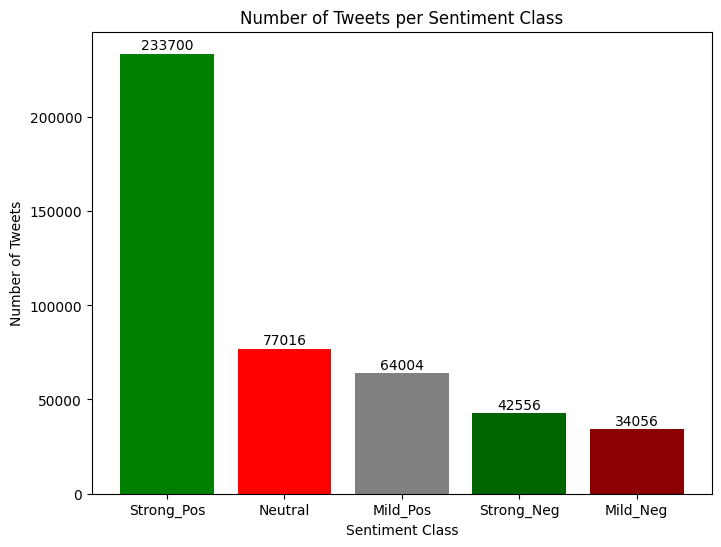

In [84]:
# Calculate the number of tweets per sentiment class
sentiment_counts = df['Sentiment'].value_counts()

print('Total Counts of all sentiment classes:\n', sentiment_counts)
print("==============")

# Plot a bar chart to visualize the distribution of tweet counts across sentiment classes
plot_sentiment_counts(sentiment_counts)

#4. Feature Extraction - Word Count and Punctuation Count

## Calculate the number of words in each tweet and store it in a new column 'word_count'

In [85]:
# Handles any non-string entries safely by assigning a count of 0
df['word_count'] = df['Tweet'].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)

### Word count distribution plot

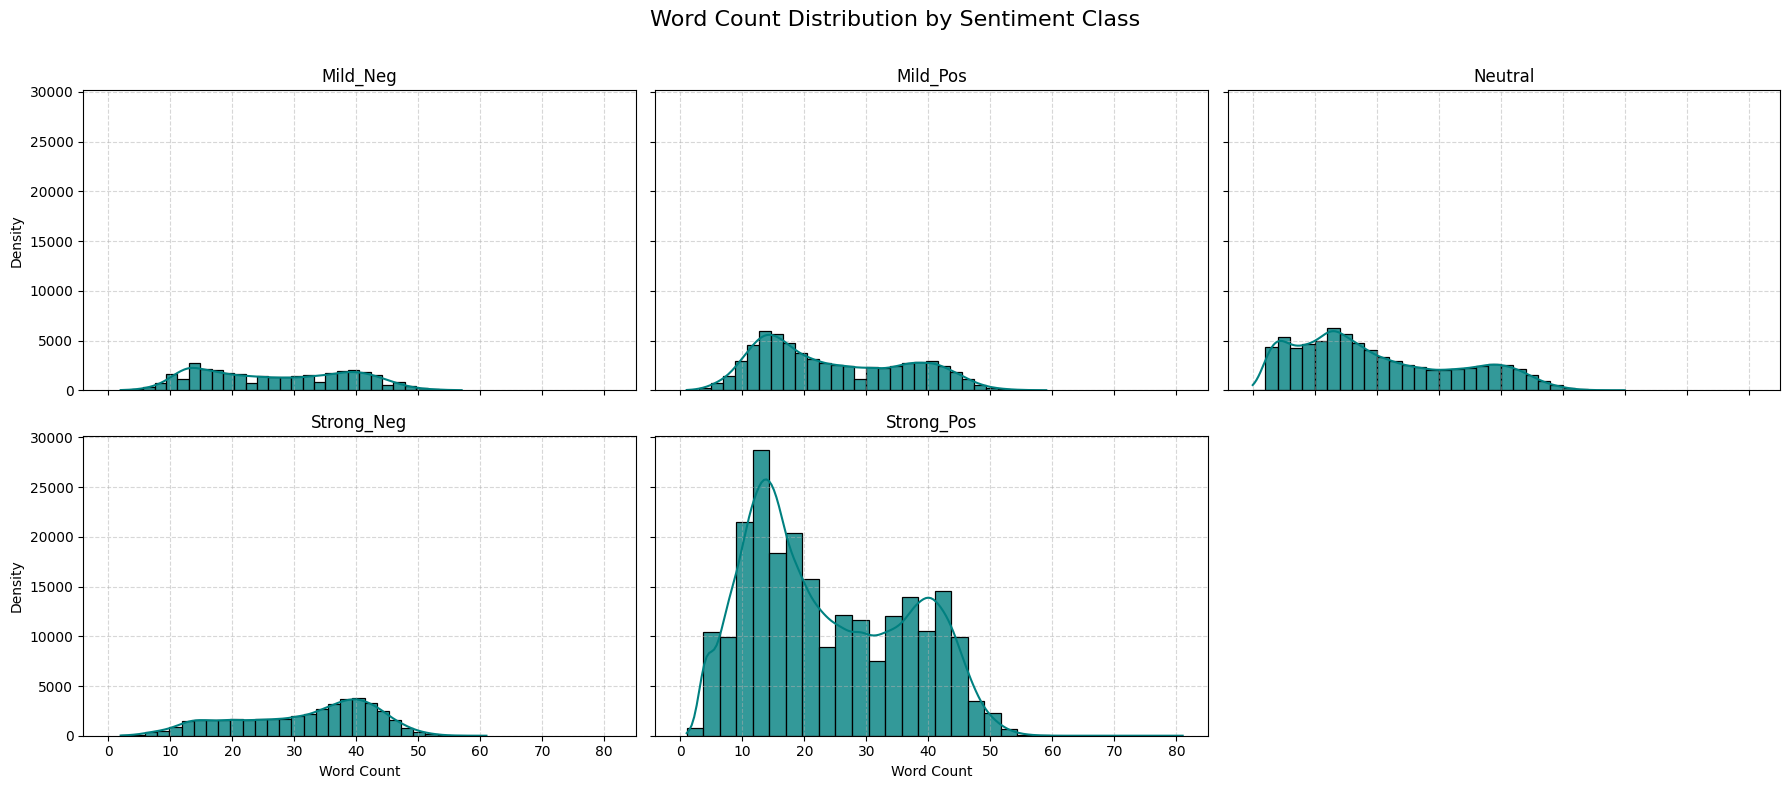

In [86]:
# Get a sorted list of unique sentiment classes in the dataset
sentiments = sorted(df['Sentiment'].unique())

# Create a 2x3 grid of subplots for plotting word count distributions per sentiment
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

# For each sentiment class, plot the distribution of word counts using a histogram + KDE
for idx, sentiment in enumerate(sentiments):
    word_counts = df[df['Sentiment'] == sentiment]['word_count']
    sns.histplot(
        word_counts,
        bins=30,
        kde=True,           # overlay a KDE
        color="teal",
        alpha=0.8,          # controls histogram fill transparency
        ax=axes[idx]
    )
    axes[idx].set_title(f"{sentiment}")
    axes[idx].set_xlabel("Word Count")
    axes[idx].set_ylabel("Density")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

# Hide any unused subplot if sentiment classes are fewer than subplot slots
if len(sentiments) < len(axes):
    for idx in range(len(sentiments), len(axes)):
        axes[idx].set_visible(False)

# Set the main title and adjust layout for the whole figure
fig.suptitle("Word Count Distribution by Sentiment Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Adding punctuation count for each tweet in the dataframe

In [87]:
df['punctuation_count'] = df['Tweet'].apply(lambda z: len([c for c in str(z) if c in string.punctuation]))

### Punctuation count distribution plot

/tmp/ipython-input-88-787223585.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(counts, bins=20, kde=True, color="purple", hist_kws={"alpha":0.5}, ax=axes[idx])
/tmp/ipython-input-88-787223585.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(counts, bins=20, kde=True, color="purple", hist

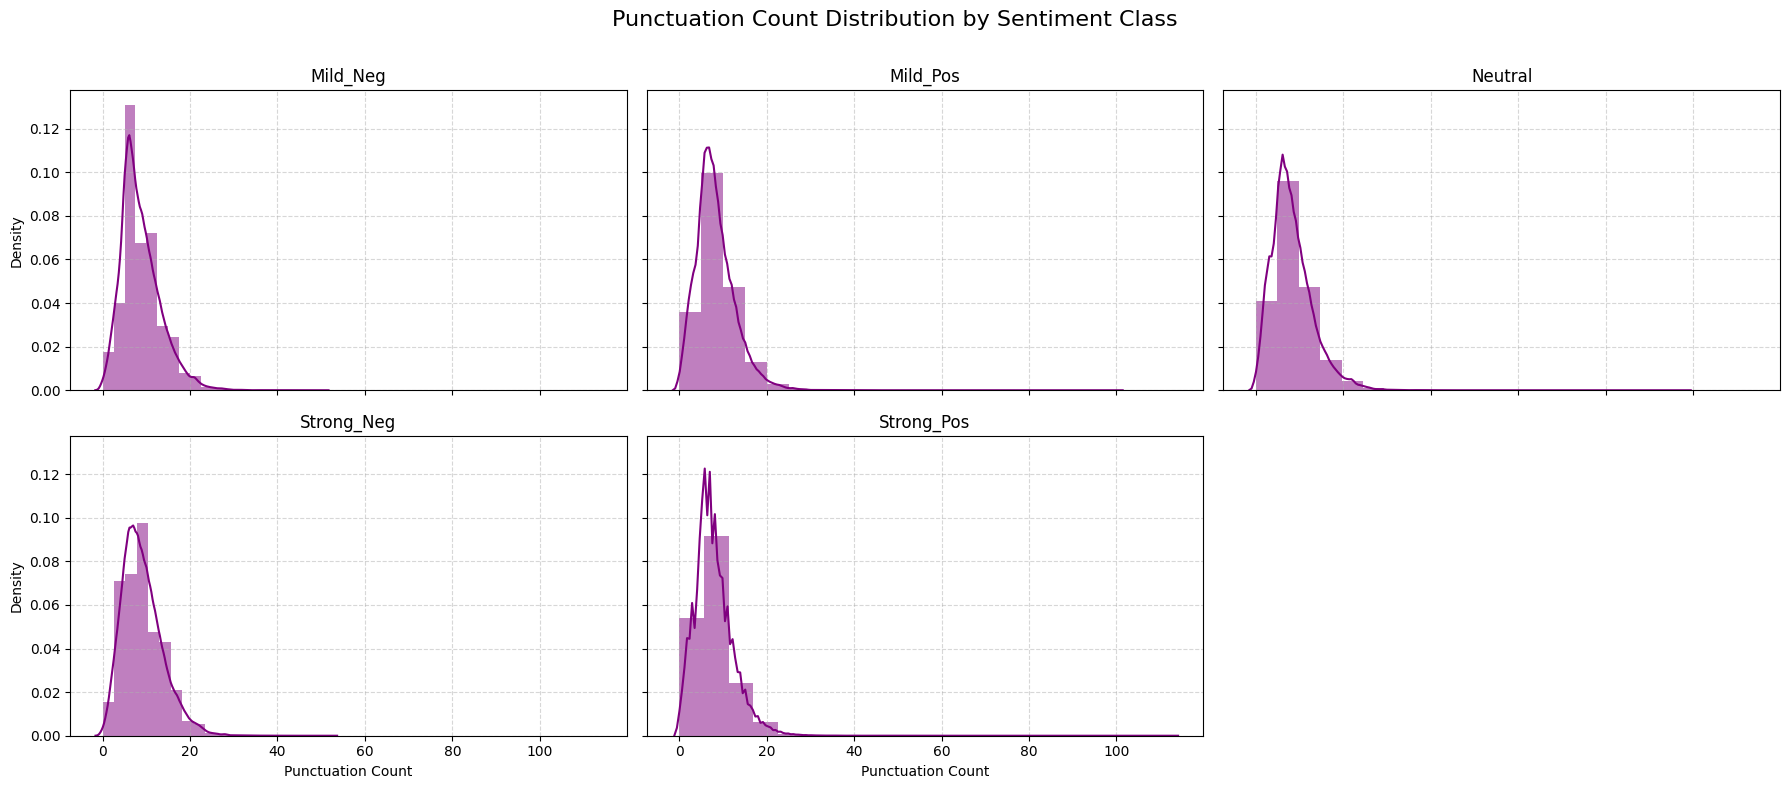

In [88]:
sentiments = sorted(df['Sentiment'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sentiment in enumerate(sentiments):
    counts = df[df['Sentiment'] == sentiment]['punctuation_count']
    sns.distplot(counts, bins=20, kde=True, color="purple", hist_kws={"alpha":0.5}, ax=axes[idx])
    axes[idx].set_title(f"{sentiment}")
    axes[idx].set_xlabel("Punctuation Count")
    axes[idx].set_ylabel("Density")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

for idx in range(len(sentiments), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Punctuation Count Distribution by Sentiment Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


#5. Handling Missing Values

## Checking for nulls

In [89]:
df.isnull().sum()

,0
Tweet,1
Sentiment,0
word_count,0
punctuation_count,0


## Displaying missing rows

In [90]:
missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows)

      Tweet Sentiment  word_count  punctuation_count
75986   NaN   Neutral           0                  0


## Dropping missing values

In [91]:
df.dropna(inplace=True)

## Rechecking info and null

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 451331 entries, 0 to 451331
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Tweet              451331 non-null  object
 1   Sentiment          451331 non-null  object
 2   word_count         451331 non-null  int64 
 3   punctuation_count  451331 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 17.2+ MB


In [93]:
df.isnull().sum()

,0
Tweet,0
Sentiment,0
word_count,0
punctuation_count,0


#6. Text Cleaning Functions and Preprocessing

###1. Demojize & count emojis

In [94]:
def demojize_text(text):
    """Return (text_without_emojis, emoji_count)."""
    if not isinstance(text, str):
        return "", 0

    # Normalize & convert emojis to aliases (with spaces as delimiters)
    text = unicodedata.normalize("NFKD", text)
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Count actual emoji characters
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    emoji_count = len(emoji_pattern.findall(text))

    # Strip out the emoji characters (we keep the aliases in the text)
    text = emoji_pattern.sub("", text)
    return text, emoji_count


###2. Clean the demojized text

In [95]:
def clean_text(text):
    """Remove URLs, mentions, hashtags, non-letters, fix contractions, etc."""
    if not isinstance(text, str):
        return ""

    # Drop any remaining non-ASCII
    text = text.encode("ascii", "ignore").decode("ascii")

    # Lowercase & expand contractions
    text = text.lower()
    text = contractions.fix(text)

    # Strip URLs, mentions, hashtags, HTML tags
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[@#]\w+", " ", text)
    text = re.sub(r"<.*?>", " ", text)

    # Remove anything that isn’t a lowercase letter or whitespace
    text = re.sub(r"[^a-z\s]", " ", text)

    # Collapse multiple spaces and trim
    return re.sub(r"\s+", " ", text).strip()


###3. Apply to your DataFrame

In [96]:
# First demojize & count
df[['text_no_emoji', 'emoji_count']] = df['Tweet'].apply(
    lambda x: pd.Series(demojize_text(x))
)

# Then clean
df['clean_tweet'] = df['text_no_emoji'].apply(clean_text)

# (Optional) drop the helper column
df.drop(columns='text_no_emoji', inplace=True)

# Quick sanity-check
print("Total emojis handled:", df['emoji_count'].sum())
print("Sample cleaned tweet:", df['clean_tweet'].iloc[0])

Total emojis handled: 0
Sample cleaned tweet: happy anniversary the day the freedumb died in the tune of don mclean s american pie


# 7. Negation Handling

##Defining negation words

In [97]:
negation_words = set(['not', 'no', 'never', "n't", 'cannot', 'neither', 'nor'])

In [98]:
def negate_text(text):
    tokens = text.split()
    negated_tokens = []
    negate = False
    negation_scope = 3  # number of words after negation to tag

    i = 0
    while i < len(tokens):
        word = tokens[i]
        if word in negation_words:
            negate = True
            negated_tokens.append(word)
            i += 1
            # Tag next few words
            for j in range(negation_scope):
                if i < len(tokens):
                    negated_tokens.append(tokens[i] + "_NEG")
                    i += 1
            negate = False
        else:
            negated_tokens.append(word)
            i += 1
    return ' '.join(negated_tokens)

In [99]:
# Apply negation handling to clean_tweet column
df['clean_tweet'] = df['clean_tweet'].apply(negate_text)

# Optionally, count how many negations were handled (e.g., count how many words got the _NEG suffix)
def count_negations(text):
    return text.count('_NEG')

df['negation_count'] = df['clean_tweet'].apply(count_negations)

total_negations = df['negation_count'].sum()
print(f"Negations Handled: {total_negations}")

Negations Handled: 330789


# 8. Tokenization and Lemmatization

### Tokenizing the words

In [100]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [101]:
from nltk.tokenize import word_tokenize
df['tokens'] = df['clean_tweet'].apply(word_tokenize)

In [102]:
df['tokens'] = df['tokens'].apply(lambda x: [w for w in x if w not in stop_words])

### Lemmatizing the tokens

In [103]:
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

In [104]:
df['clean_tweet'] = df['tokens'].apply((lambda x: ' '.join(x)))

In [105]:
print(df.columns)

Index(['Tweet', 'Sentiment', 'word_count', 'punctuation_count', 'emoji_count',
       'clean_tweet', 'negation_count', 'tokens'],
      dtype='object')


# 9. Word Cloud and Frequent Words Visualization


### **Word** cloud for 5 classes (Mild_Neg, Strong_Neg, Neutral, Mild_Pos, Strong_Pos)

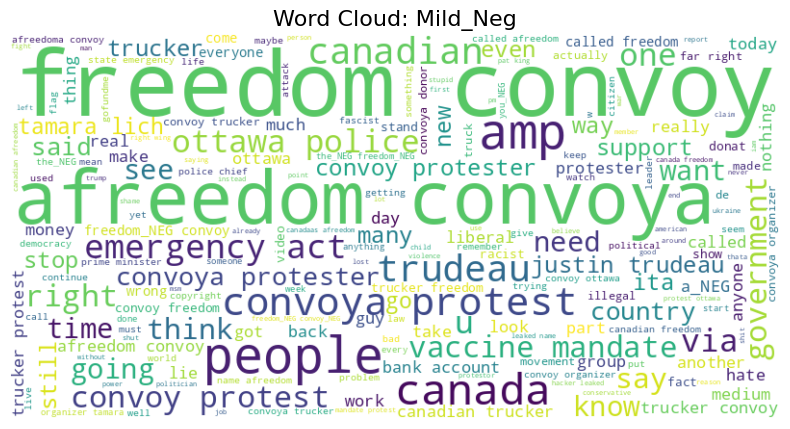

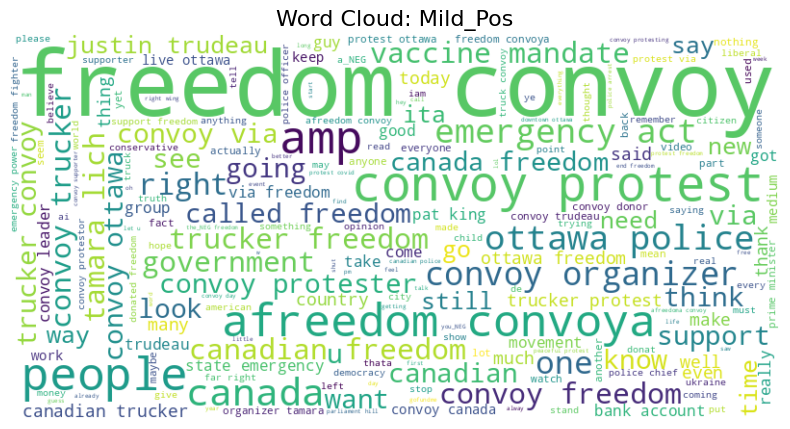

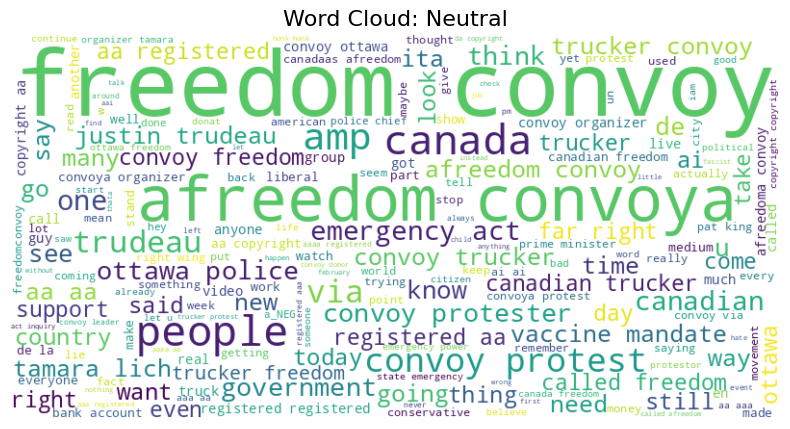

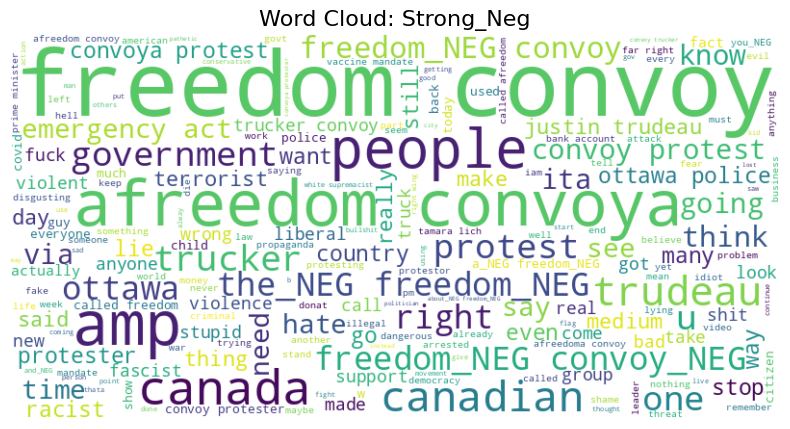

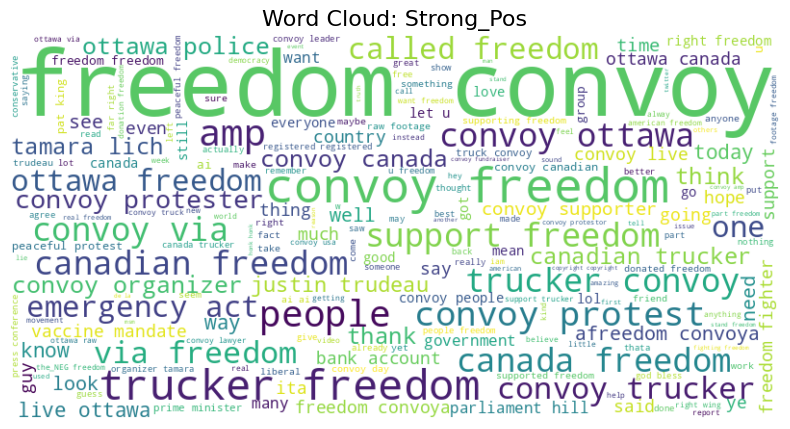

In [106]:
classes = sorted(df['Sentiment'].unique())

img_path = None

for sentiment in classes:
    texts = df[df['Sentiment'] == sentiment]['clean_tweet']
    if img_path is not None:
        mask = np.array(Image.open(img_path))
    else:
        mask = None
    wc = WordCloud(
        stopwords=STOPWORDS,
        mask=mask,
        background_color="white",
        contour_width=2,
        contour_color="black",
        max_words=200,
        max_font_size=256,
        random_state=42,
        width=800 if mask is None else mask.shape[1],
        height=400 if mask is None else mask.shape[0]
    ).generate(' '.join(map(str, texts.dropna())))
    plt.figure(figsize=(8, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis('off')
    plt.title(f"Word Cloud: {sentiment}", fontsize=16)
    plt.tight_layout()
    plt.show()


### Top 20 most frequent words for all 5 classes

/tmp/ipython-input-107-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


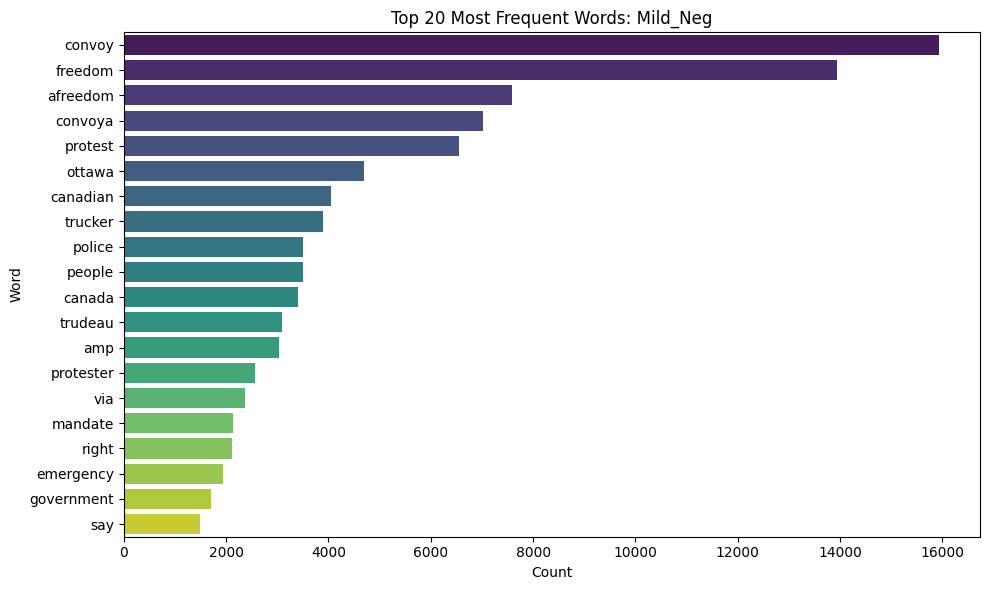

/tmp/ipython-input-107-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


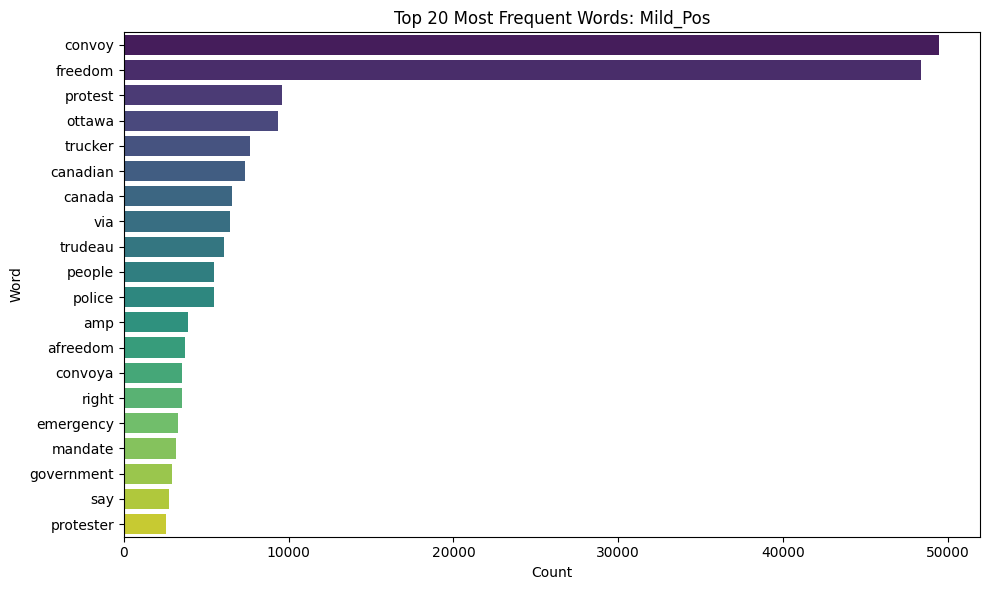

/tmp/ipython-input-107-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


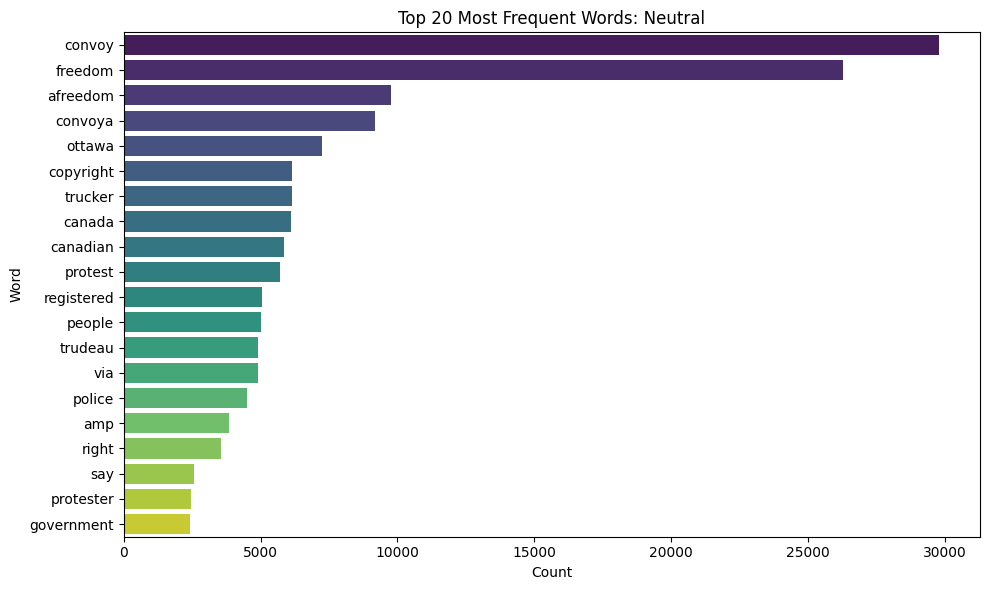

/tmp/ipython-input-107-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


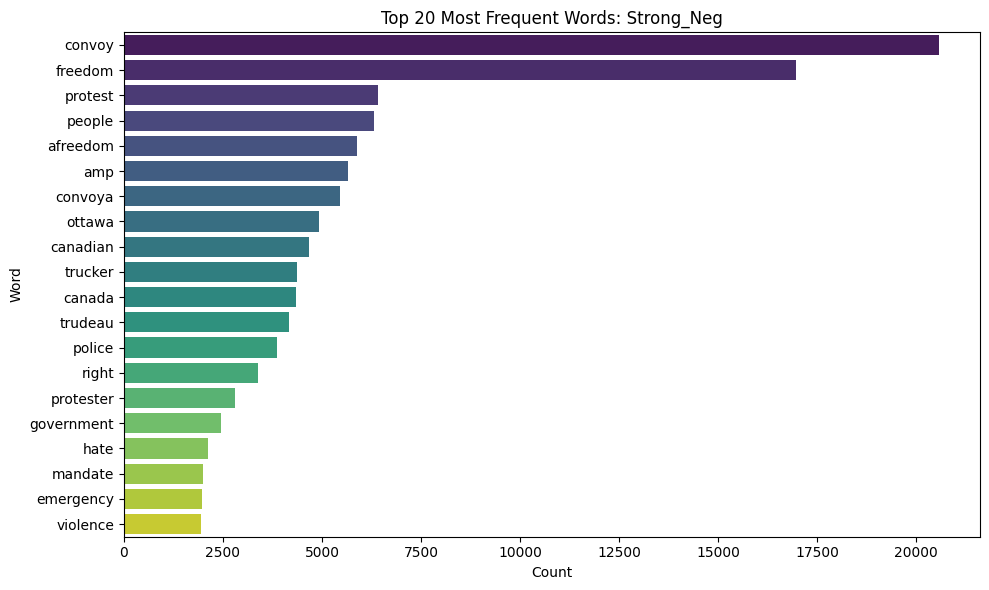

/tmp/ipython-input-107-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


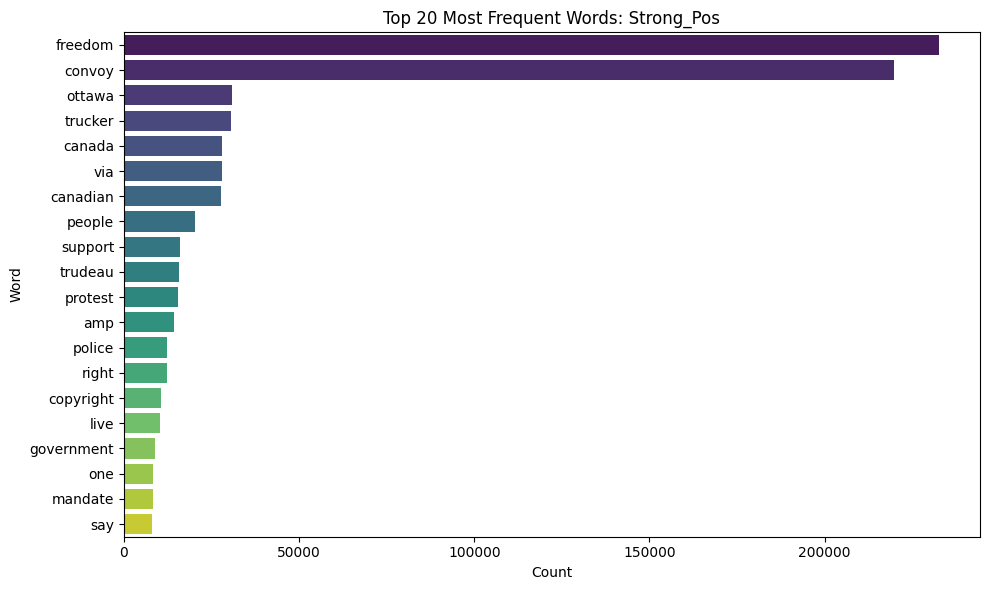

In [107]:
def plot_top_words(texts, n=20, title=None):
    words = [
        word.lower() for text in texts
        for word in word_tokenize(text)
        if word.lower() not in STOPWORDS and len(word) > 2 and word.isalpha()
    ]
    word_counts = Counter(words)
    top_words = word_counts.most_common(n)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=[count for word, count in top_words],
        y=[word for word, count in top_words],
        palette='viridis'
    )
    plt.title(title or f'Top {n} Most Frequent Words')
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.show()

# For all classes
for sentiment in classes:
    texts = df[df['Sentiment'] == sentiment]['clean_tweet']
    plot_top_words(
        texts, n=20, title=f"Top 20 Most Frequent Words: {sentiment}"
    )

# 10. Removing Empty Tweets After Cleaning

In [108]:
total_tweet = len(df)
empt_str = df['clean_tweet'].eq('').sum()
print(f"Total tweets: {total_tweet:,}")
empt_str_removed = empt_str
print(f"Total empty strings (after cleaning): {empt_str_removed}")

Total tweets: 451,331
Total empty strings (after cleaning): 10167


## Removing the row from dataframe which has empty string after cleaning the data

In [109]:
df = df[df['clean_tweet'].str.strip().astype(bool)]

In [110]:
total_tweet = len(df)
empt_str = df['clean_tweet'].eq('').sum()
print(f"Total tweets: {total_tweet:,}")
print(f"Total empty strings (after cleaning): {empt_str:,}")

Total tweets: 441,164
Total empty strings (after cleaning): 0


# 11. Consolidating Sentiment Classes

## Mapping original 5 sentiment labels into 3 classes: negative, neutral, positive

In [111]:
def consolidate_label(x):
    if x in ['Mild_Neg', 'Strong_Neg']:
        return 'negative'
    elif x in ['Mild_Pos', 'Strong_Pos']:
        return 'positive'
    else:
        return 'neutral'

df['sentiment_consolidated'] = df['Sentiment'].apply(consolidate_label)


/tmp/ipython-input-111-4056856513.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_consolidated'] = df['Sentiment'].apply(consolidate_label)


## Plotting distribution after consolidation

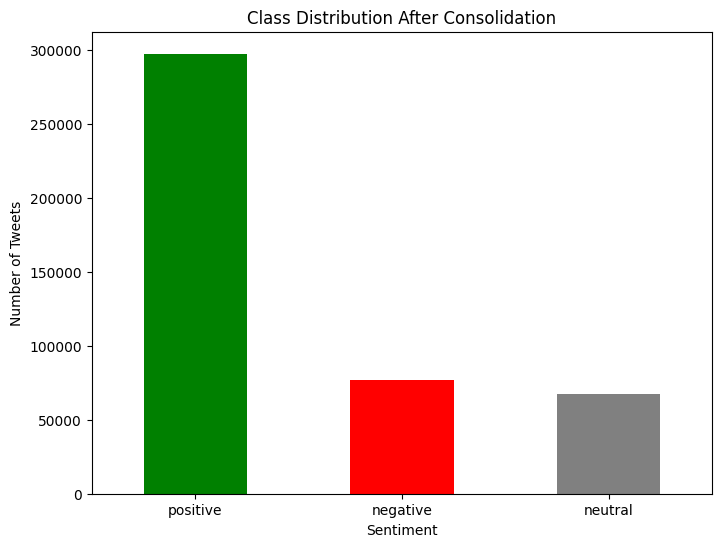

In [112]:
df['sentiment_consolidated'].value_counts().plot(kind='bar', color=['green', 'red', 'grey'])
plt.title('Class Distribution After Consolidation')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()


## Printing counts and proportions

In [113]:
print("Counts:")
print(df['sentiment_consolidated'].value_counts())

print("\nProportions:")
print(df['sentiment_consolidated'].value_counts(normalize=True))


Counts:
sentiment_consolidated
positive    297459
negative     76569
neutral      67136
Name: count, dtype: int64

Proportions:
sentiment_consolidated
positive    0.674259
negative    0.173561
neutral     0.152179
Name: proportion, dtype: float64


There is class imbalance in the dataset as the tweet with sentiment positive are more than the negative and neutral.

# 12. Train / Validation / Test Split
### (before Feature engineering, tf-idf, PCA, Lexicon Score Feature and Label Encoding to avoid Data Leakage)

In [114]:
from sklearn.model_selection import train_test_split

# Step 1: Define inputs
X_full = df[['Tweet', 'clean_tweet']]
y_full = df['sentiment_consolidated']

# Step 2: First split - Separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

# Step 3: Second split - From remaining, get train (60%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)  # 0.25 x 0.8 = 0.2

# Step 4: Reset indices
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# ✅ Final Proportions: 60% Train / 20% Val / 20% Test


#13. Handle class imbalance on TRAIN only

In [115]:
from imblearn.over_sampling import RandomOverSampler

# Upsample all minority classes to match the majority
ros = RandomOverSampler(
    sampling_strategy='not majority',
    random_state=42
)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

# Overwrite the original train splits
X_train, y_train = X_train_res, y_train_res

#V erify new training-class counts
print("New training set class distribution:")
print(y_train.value_counts())

New training set class distribution:
sentiment_consolidated
positive    178475
negative    178475
neutral     178475
Name: count, dtype: int64


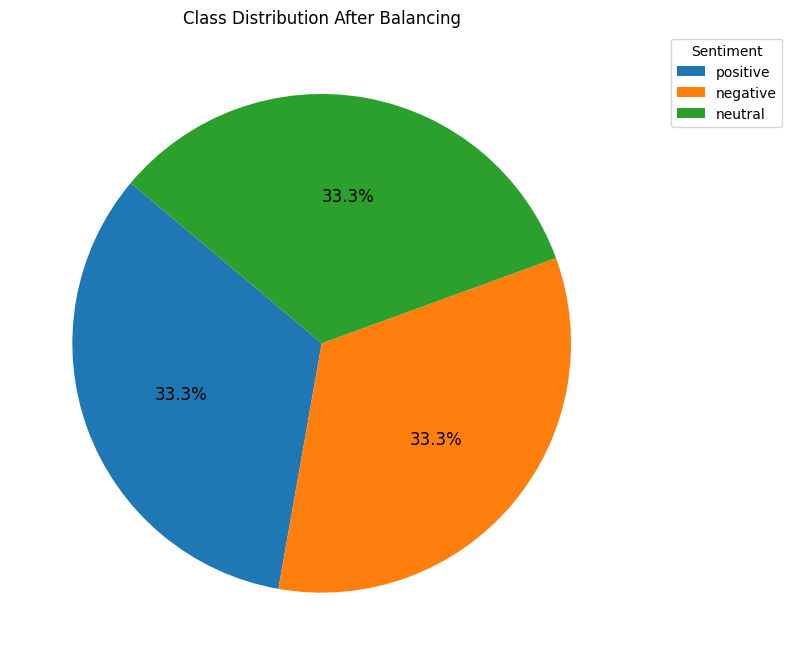

In [116]:
counts = y_train.value_counts()
labels = counts.index
sizes  = counts.values

plt.figure(figsize=(8,8))
plt.pie(
    sizes,
    labels=None,               # turn off direct labels
    autopct='%1.1f%%',         # show percent on slices
    startangle=140,            # rotate for better layout
    textprops={'fontsize': 12} # make slice text legible
)
plt.title('Class Distribution After Balancing')

# move labels into a legend on the right
plt.legend(
    labels,
    title='Sentiment',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()


#14. Feature Engineering: Tweet Length and Hashtag Count


In [117]:
# Feature 1: Tweet Length (based on original tweet text)
X_train['tweet_length'] = X_train['Tweet'].apply(len)
X_val['tweet_length'] = X_val['Tweet'].apply(len)
X_test['tweet_length'] = X_test['Tweet'].apply(len)

# Feature 2: Hashtag Count (using regex)
import re
X_train['num_hashtags'] = X_train['Tweet'].apply(lambda x: len(re.findall(r"#\w+", str(x))))
X_val['num_hashtags'] = X_val['Tweet'].apply(lambda x: len(re.findall(r"#\w+", str(x))))
X_test['num_hashtags'] = X_test['Tweet'].apply(lambda x: len(re.findall(r"#\w+", str(x))))


#15. TF-IDF Vectorization and PCA Visualization

In [118]:
# 1. Vectorization (fit only on training data)
tf_vectorizer = TfidfVectorizer(max_features=500)
X_train_vec = tf_vectorizer.fit_transform(X_train['clean_tweet'])
X_val_vec   = tf_vectorizer.transform(X_val['clean_tweet'])
X_test_vec  = tf_vectorizer.transform(X_test['clean_tweet'])

In [119]:
# 2. Incremental PCA (fit only on training data, in batches)
n_components = 2
batch_size   = 10000

ipca = IncrementalPCA(n_components=n_components)

# 2a) partial_fit in batches on TRAIN
n_samples = X_train_vec.shape[0]
for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    X_batch = X_train_vec[start:end].toarray()
    ipca.partial_fit(X_batch)

# 2b) transform TRAIN in batches and stack
train_pca_batches = []
for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    X_batch = X_train_vec[start:end].toarray()
    train_pca_batches.append(ipca.transform(X_batch))
X_train_pca = np.vstack(train_pca_batches)

# 2c) transform VAL and TEST (smaller, can toarray() once)
X_val_pca  = ipca.transform(X_val_vec.toarray())
X_test_pca = ipca.transform(X_test_vec.toarray())

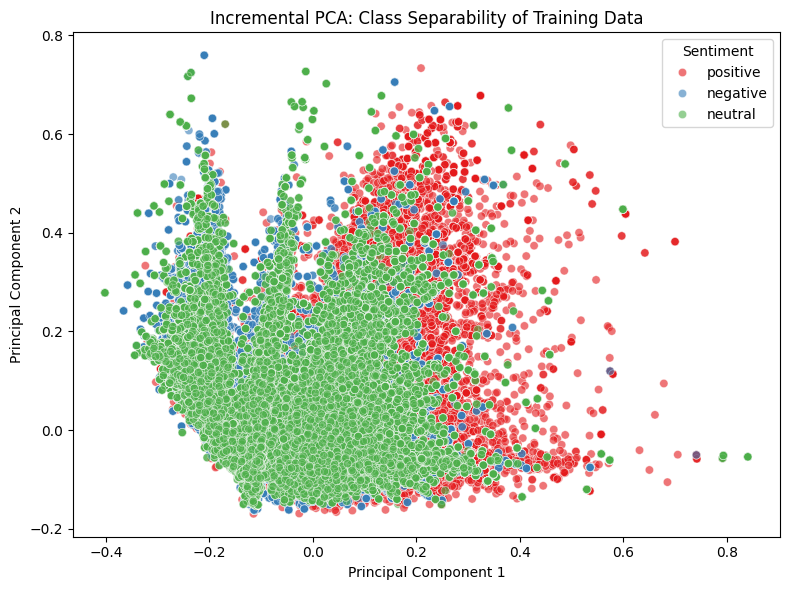

In [120]:
# 3. Visualize PCA (train set only)
df_pca = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'sentiment': y_train
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='sentiment',
    palette='Set1',
    alpha=0.6
)
plt.title('Incremental PCA: Class Separability of Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

#16. Lexicon Score Feature

In [121]:
pos_words = set(opinion_lexicon.positive())
neg_words = set(opinion_lexicon.negative())

In [122]:
def lexicon_score(text, pos_words, neg_words):
    tokens = text.split()
    pos = sum(1 for w in tokens if w in pos_words)
    neg = sum(1 for w in tokens if w in neg_words)
    return pos - neg


In [123]:
# Apply lexicon_score feature to all three sets safely
X_train['lexicon_score'] = X_train['clean_tweet'].apply(lambda x: lexicon_score(x, pos_words, neg_words))
X_val['lexicon_score'] = X_val['clean_tweet'].apply(lambda x: lexicon_score(x, pos_words, neg_words))
X_test['lexicon_score'] = X_test['clean_tweet'].apply(lambda x: lexicon_score(x, pos_words, neg_words))


#17. Label Encoding


In [124]:
# Initialize and fit only on training labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded   = label_encoder.transform(y_val)
y_test_encoded  = label_encoder.transform(y_test)

# Optional: to check mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Mapping:", label_mapping)


Label Encoding Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [125]:
label_encoder.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [126]:
df.tail()

,Tweet,Sentiment,word_count,punctuation_count,emoji_count,clean_tweet,negation_count,tokens,sentiment_consolidated
451327,"Gaza; Peace n' Freedom - Viva Palestina convoy enters Algeria: \r\nThe Viva Palestina convoy, the massive relief c.. http://tinyurl.com/cajylt",Strong_Pos,19,12,0,gaza peace n freedom viva palestina convoy enters algeria viva palestina convoy massive relief c,0,"[gaza, peace, n, freedom, viva, palestina, convoy, enters, algeria, viva, palestina, convoy, massive, relief, c]",positive
451328,"Face of Defense: Soldier Finds Freedom in U.S., Fights for Freedom in Iraq: CONVOY SUPPORT CEN... http://tinyurl.com/dyth62 RT @freerepublic",Strong_Pos,19,14,0,face defense soldier find freedom fight freedom iraq convoy support cen rt,0,"[face, defense, soldier, find, freedom, fight, freedom, iraq, convoy, support, cen, rt]",positive
451329,"Face of Defense: Soldier Finds Freedom in U.S., Fights for Freedom in Iraq: CONVOY SUPPORT CENTER SCANIA, Iraq, .. http://tinyurl.com/dyth62",Strong_Pos,20,14,0,face defense soldier find freedom fight freedom iraq convoy support center scania iraq,0,"[face, defense, soldier, find, freedom, fight, freedom, iraq, convoy, support, center, scania, iraq]",positive
451330,"Gaza; Peace n' Freedom - ""Israel stops aid convoy en route to Gaza from Hebron"": \r\nMa&quot;an News Agency report.. http://tinyurl.com/7mguhc",Strong_Pos,20,15,0,gaza peace n freedom israel stop aid convoy en route gaza hebron quot news agency report,0,"[gaza, peace, n, freedom, israel, stop, aid, convoy, en, route, gaza, hebron, quot, news, agency, report]",positive
451331,@convoy 83 yes! get on freedom server!,Strong_Pos,7,3,0,yes get freedom server,0,"[yes, get, freedom, server]",positive


#18. Exporting Processed Data and Model Artifacts

## Data Preprocessing Checklist

In [127]:
# 1. Regex usage check (approximate by counting regex calls in clean_text)
print("- Regex Cleaning: Applied in clean_text function")

# 2. Emoji Handling
total_emoji = df['emoji_count'].sum() if 'emoji_count' in df.columns else 0
print(f"- Emoji Handling: Done, total emojis handled = {total_emoji}")

# 3. Slang Handling
total_slang = df['slang_count'].sum() if 'slang_count' in df.columns else 0
print(f"- Slang Handling: Done, total slang replacements = {total_slang}")

# 4. Abbreviation Handling (if combined with slang_dict, same as slang_count)
total_abbr = df['abbr_count'].sum() if 'abbr_count' in df.columns else 0
print(f"- Abbreviation Handling: {'Done' if total_abbr>0 else 'Not separated from slang'}, total abbreviations replaced = {total_abbr}")

# 5. Negation Handling
total_negations = df['negation_count'].sum() if 'negation_count' in df.columns else 0
print(f"- Negation Handling: {'Done' if total_negations>0 else 'Not detected'}, total negations tagged = {total_negations}")

# 6. Empty tweets removed
empty_count = df['clean_tweet'].eq('').sum()
print(f"- Empty Tweets Removed: {'Yes, ' + str(empt_str_removed) + ' removed' if empt_str_removed>0 else 'No'}, remaining empty tweets = {empty_count}")

# 7. Class distribution after consolidation
if 'sentiment_consolidated' in df.columns:
    print("- Sentiment Classes Distribution:")
    print(df['sentiment_consolidated'].value_counts())
else:
    print("- Sentiment Classes Distribution: Not found")

# 8. Train/Val/Test Split Sizes (if variables exist)
try:
    print(f"- Train size: {len(X_train)}")
    print(f"- Validation size: {len(X_val)}")
    print(f"- Test size: {len(X_test)}")
except NameError:
    print("- Train/Val/Test Split: Variables not found")

# 9. Feature Columns Present (tweet_length, num_hashtags, lexicon_score)
features = ['tweet_length', 'num_hashtags', 'lexicon_score']
for feat in features:
    present = feat in df.columns or ('X_train' in globals() and feat in X_train.columns)
    print(f"- Feature '{feat}': {'Present' if present else 'Missing'}")

print("========================================")


- Regex Cleaning: Applied in clean_text function
- Emoji Handling: Done, total emojis handled = 0
- Slang Handling: Done, total slang replacements = 0
- Abbreviation Handling: Not separated from slang, total abbreviations replaced = 0
- Negation Handling: Done, total negations tagged = 330789
- Empty Tweets Removed: Yes, 10167 removed, remaining empty tweets = 0
- Sentiment Classes Distribution:
sentiment_consolidated
positive    297459
negative     76569
neutral      67136
Name: count, dtype: int64
- Train size: 535425
- Validation size: 88233
- Test size: 88233
- Feature 'tweet_length': Present
- Feature 'num_hashtags': Present
- Feature 'lexicon_score': Present


## Exporting train, val, test sets (features and labels) as CSV

In [128]:
X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)

y_train.to_frame().to_csv('y_train.csv', index=False)
y_val.to_frame().to_csv('y_val.csv', index=False)
y_test.to_frame().to_csv('y_test.csv', index=False)

## Exporting the label encoder

In [130]:
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)